In [1]:
# importing major libraries

import numpy as np 
import pandas as pd 

df = pd.read_csv('covid.csv')

In [2]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [3]:
df.isnull().sum()
df.isnull().mean()

age          0.0
gender       0.0
fever        0.1
cough        0.0
city         0.0
has_covid    0.0
dtype: float64

In [4]:
df.shape

(100, 6)

In [5]:
from sklearn.model_selection import train_test_split
x = df.iloc[:,0:-1]
y = df.has_covid

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
x_train.isnull().sum()

age       0
gender    0
fever     9
cough     0
city      0
dtype: int64

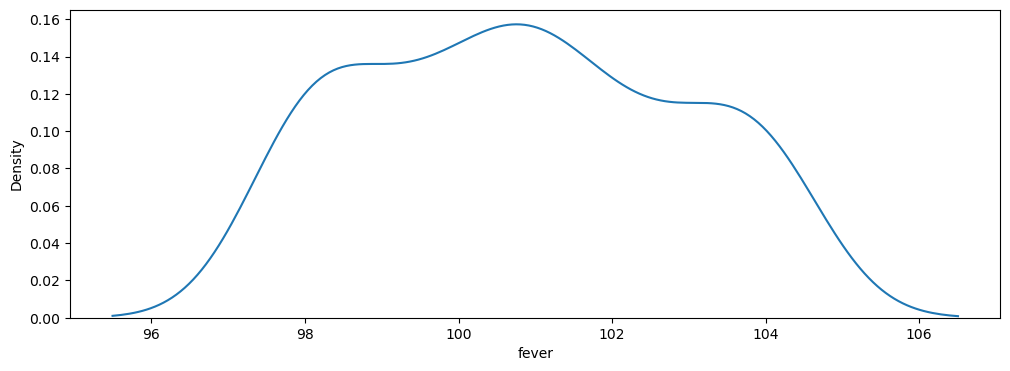

In [8]:
# imputers 
import seaborn as sns 
import matplotlib.pyplot as plt 
plt.figure(figsize=(12,4))
sns.kdeplot(df.fever)
plt.show()

In [9]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='mean')

# strategy, mean , median, constant, most_frequent(mode)

In [10]:
si

SimpleImputer()

In [11]:
x_train_fever = si.fit_transform(x_train[['fever']])
x_test_fever = si.transform(x_test[['fever']])

In [12]:
# scaling 

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc 

StandardScaler()

In [13]:
# scaling 
sc.fit(x_train[['age','fever']])
x_train_sc = pd.DataFrame(sc.transform(x_train[['age','fever']]),columns=sc.get_feature_names_out())
x_test_sc = pd.DataFrame(sc.transform(x_test[['age','fever']]),columns=sc.get_feature_names_out())

# sc.transform(x_test[['age','fever']])

In [14]:
# encoding 

In [15]:
df.cough.unique()
# ordinal encoding

from sklearn.preprocessing import OrdinalEncoder
loe = ['Mild', 'Strong']
oe = OrdinalEncoder(categories=[loe],dtype=int)
oe

OrdinalEncoder(categories=[['Mild', 'Strong']], dtype=<class 'int'>)

In [16]:
oe.fit(x_train[['cough']])

OrdinalEncoder(categories=[['Mild', 'Strong']], dtype=<class 'int'>)

In [17]:
# transformation 

x_train_cough = pd.DataFrame(oe.transform(x_train[['cough']]),columns=oe.get_feature_names_out())
x_test_cough = pd.DataFrame(oe.transform(x_test[['cough']]),columns=oe.get_feature_names_out())

In [18]:
# df
df.city.unique()

array(['Kolkata', 'Delhi', 'Mumbai', 'Bangalore'], dtype=object)

In [19]:
from sklearn.preprocessing import OneHotEncoder

ohecity = OneHotEncoder(sparse_output=False)
gender = ['Female','Male']
ohegender = OneHotEncoder(categories=[gender],sparse_output=False,drop='first')

In [20]:
ohecity.fit(x_train[['city']])

OneHotEncoder(sparse_output=False)

In [21]:
x_train_city = pd.DataFrame(ohecity.transform(x_train[['city']]),columns=ohecity.get_feature_names_out())
x_test_city = pd.DataFrame(ohecity.transform(x_test[['city']]),columns=ohecity.get_feature_names_out())


In [22]:
ohegender.fit(x_train[['gender']])

OneHotEncoder(categories=[['Female', 'Male']], drop='first',
              sparse_output=False)

In [23]:
x_train_gender = pd.DataFrame(ohegender.transform(x_train[['gender']]),columns=ohegender.get_feature_names_out())
x_test_gender = pd.DataFrame(ohegender.transform(x_test[['gender']]),columns=ohegender.get_feature_names_out())

In [24]:
x_train_gender
x_train_city
x_train_cough
x_train_fever
x_train_sc

,age,fever
0,1.566141,0.000000
1,-1.558945,-0.491423
2,-0.983271,-0.491423
3,-0.654315,-0.491423
4,1.237185,0.982846
...,...,...
75,-0.777674,0.491423
76,1.319424,1.474269
77,0.332554,1.474269
78,1.607261,0.491423
